In [28]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [29]:
pip install matplotlib seaborn jupyter 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [30]:
import pandas as pd

df =pd.read_csv("Transactions.csv")

df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
dtypes: float64(1), int64(5), str(5)
memory usage: 12.5 MB


In [32]:
df.isnull().sum()

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df["Revenue"]= df["transaction_qty"] * df["unit_price"]  
df[["transaction_qty","unit_price","Revenue"]].head()

,transaction_qty,unit_price,Revenue
0,2,3.0,6.0
1,2,3.1,6.2
2,2,4.5,9.0
3,1,2.0,2.0
4,2,3.1,6.2


In [35]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 698812.3300000001


Top 10 Selling Products

In [36]:
top_products = df.groupby('product_detail')['transaction_qty'].sum()

top_products = top_products.sort_values(ascending=False)

top_products.head(10)

product_detail
Earl Grey Rg                   4708
Dark chocolate Lg              4668
Morning Sunrise Chai Rg        4643
Latte                          4602
Peppermint Rg                  4564
Columbian Medium Roast Rg      4547
Traditional Blend Chai Rg      4512
Latte Rg                       4497
Our Old Time Diner Blend Sm    4484
Serenity Green Tea Rg          4477
Name: transaction_qty, dtype: int64

Bottom 10 Selling Products

In [37]:
top_products.tail(10)

product_detail
Traditional Blend Chai          153
Lemon Grass                     152
Primo Espresso Roast            150
Chili Mayan                     148
Columbian Medium Roast          148
Jamacian Coffee River           146
Earl Grey                       142
Guatemalan Sustainably Grown    134
Spicy Eye Opener Chai           122
Dark chocolate                  118
Name: transaction_qty, dtype: int64

VISUALIZATION

In [38]:
pip install matplotlib 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


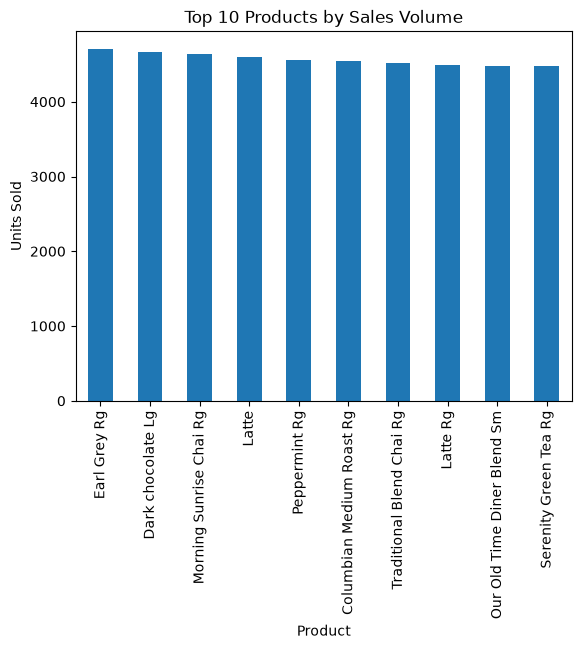

In [39]:
import matplotlib.pyplot as plt

top_products.head(10).plot(kind='bar')

plt.title('Top 10 Products by Sales Volume')
plt.xlabel('Product')
plt.ylabel('Units Sold')
plt.show()

Revenue Contribution Analysis

In [40]:
product_revenue = df.groupby('product_detail')['Revenue'].sum()

product_revenue = product_revenue.sort_values(ascending=False)

product_revenue.head(10)

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Latte                           17257.50
Jamaican Coffee River Lg        16481.25
Sustainably Grown Organic Rg    16233.75
Cappuccino                      15997.50
Brazilian Lg                    15109.50
Name: Revenue, dtype: float64

Top 10 Revenue-Generating Products

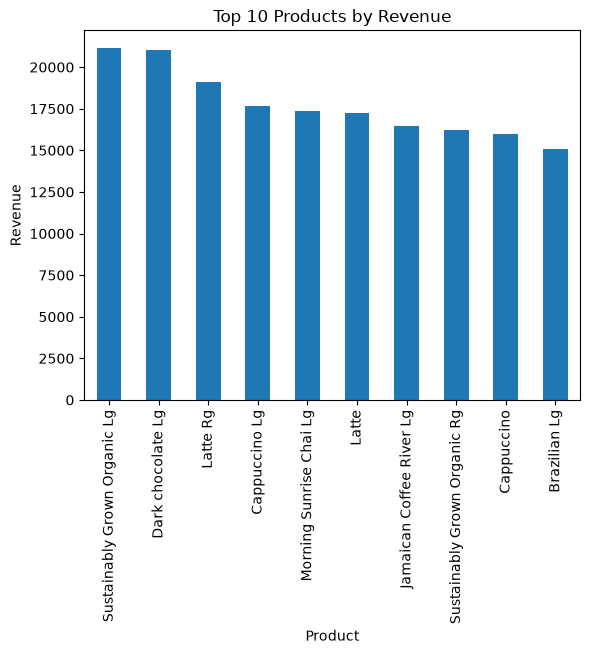

In [41]:
import matplotlib.pyplot as plt

product_revenue.head(10).plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

In [42]:
category_revenue = df.groupby(
    'product_category'
)['Revenue'].sum().sort_values(ascending=False)

print(category_revenue)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: Revenue, dtype: float64


Category Revenue Share (%)

In [43]:
category_share = (
    category_revenue / category_revenue.sum()
) * 100

round(category_share, 2)

product_category
Coffee                38.63
Tea                   28.11
Bakery                11.78
Drinking Chocolate    10.36
Coffee beans           5.74
Branded                1.95
Loose Tea              1.60
Flavours               1.20
Packaged Chocolate     0.63
Name: Revenue, dtype: float64

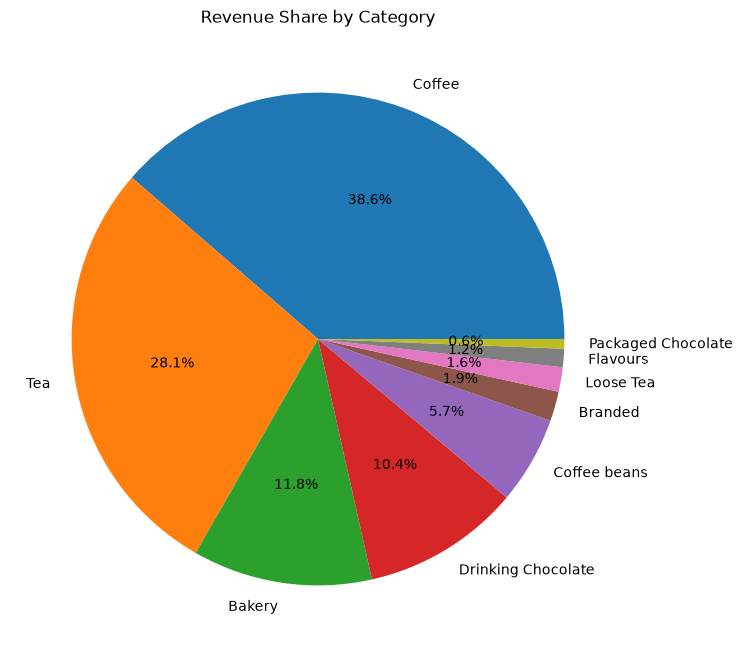

In [45]:
import matplotlib.pyplot as plt

category_revenue.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Revenue Share by Category')
plt.ylabel('')
plt.show()

Pareto Analysis (80/20 Rule)

In [47]:
product_revenue = df.groupby(
    'product_detail'
)['Revenue'].sum().sort_values(
    ascending=False
)

pareto = product_revenue.reset_index()

pareto.columns = ['Product', 'Revenue']

pareto['Cumulative Revenue'] = (
    pareto['Revenue'].cumsum()
)

pareto['Cumulative %'] = (
    pareto['Cumulative Revenue']
    / pareto['Revenue'].sum()
) * 100

pareto.head()

,Product,Revenue,Cumulative Revenue,Cumulative %
0,Sustainably Grown Organic Lg,21151.75,21151.75,3.026814
1,Dark chocolate Lg,21006.00,42157.75,6.032771
2,Latte Rg,19112.25,61270.00,8.767733
3,Cappuccino Lg,17641.75,78911.75,11.292266
4,Morning Sunrise Chai Lg,17384.00,96295.75,13.779916


In [48]:
pareto[pareto['Cumulative %'] <= 80]

,Product,Revenue,Cumulative Revenue,Cumulative %
0,Sustainably Grown Organic Lg,21151.75,21151.75,3.026814
1,Dark chocolate Lg,21006.00,42157.75,6.032771
2,Latte Rg,19112.25,61270.00,8.767733
3,Cappuccino Lg,17641.75,78911.75,11.292266
4,Morning Sunrise Chai Lg,17384.00,96295.75,13.779916
5,Latte,17257.50,113553.25,16.249463
6,Jamaican Coffee River Lg,16481.25,130034.50,18.607929
7,Sustainably Grown Organic Rg,16233.75,146268.25,20.930977
8,Cappuccino,15997.50,162265.75,23.220219
9,Brazilian Lg,15109.50,177375.25,25.382387


In [49]:
summary = df.groupby('product_detail').agg({
    'transaction_qty':'sum',
    'Revenue':'sum'
})

summary.head()

,transaction_qty,Revenue
product_detail,,
Almond Croissant,1911,7168.13
Brazilian - Organic,214,3852.00
Brazilian Lg,4317,15109.50
Brazilian Rg,4385,13155.00
Brazilian Sm,4310,9482.00


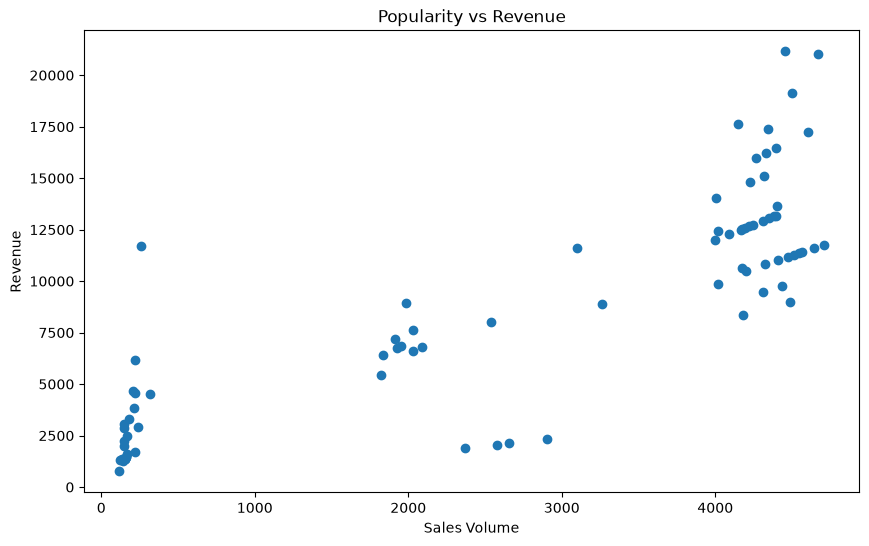

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    summary['transaction_qty'],
    summary['Revenue']
)

plt.xlabel('Sales Volume')
plt.ylabel('Revenue')
plt.title('Popularity vs Revenue')

plt.show()

Product Efficiency Score

In [51]:
efficiency = df.groupby(
    'product_detail'
)['Revenue'].sum().sort_values(
    ascending=False
)

efficiency.head()

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Name: Revenue, dtype: float64